In [1]:
# Standard libs
import os
import random
import warnings

# Data science
import numpy as np
import pandas as pd
from sklearn.utils import shuffle

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility + warnings
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
warnings.filterwarnings("ignore")

# sklearn utilities
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_auc_score,
    roc_curve,
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn import tree

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [60]:
df = pd.read_csv('/content/drive/MyDrive/ML/ModelHub/Churn/Telco-Customer-Churn.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.shape

(7043, 21)

In [6]:
df.isna().sum().sum()

np.int64(0)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
numerical = ['tenure','MonthlyCharges','SeniorCitizen']

for col in numerical:
  print(f"\n{col}")
  print(f"  Range      : {df[col].min():.2f} to {df[col].max():.2f}")
  print(f"  Mean       : {df[col].mean():.2f}")
  print(f"  Median     : {df[col].median():.2f}")
  print(f"  Std Dev    : {df[col].std():.2f}")


tenure
  Range      : 0.00 to 72.00
  Mean       : 32.37
  Median     : 29.00
  Std Dev    : 24.56

MonthlyCharges
  Range      : 18.25 to 118.75
  Mean       : 64.76
  Median     : 70.35
  Std Dev    : 30.09

SeniorCitizen
  Range      : 0.00 to 1.00
  Mean       : 0.16
  Median     : 0.00
  Std Dev    : 0.37


In [9]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print("Churn Counts:")
print(churn_counts)
print("\nChurn Percentages:")
print(churn_pct.map('{:.2f}%'.format))

print(f"\nClass Imbalance Ratio (No:Yes): {churn_counts['No']/churn_counts['Yes']:.2f}:1")

Churn Counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentages:
Churn
No     73.46%
Yes    26.54%
Name: proportion, dtype: object

Class Imbalance Ratio (No:Yes): 2.77:1


In [10]:
senior_counts = df['SeniorCitizen'].value_counts().sort_index()
senior_pct = df['SeniorCitizen'].value_counts(normalize=True).sort_index() * 100

print("SeniorCitizen (0=No, 1=Yes):")
print(senior_counts)
print("\nPercentages:")
print(senior_pct.map('{:.2f}%'.format))
print(f"Percentage of seniors: {(df['SeniorCitizen'] == 1).mean()*100:.2f}%")

SeniorCitizen (0=No, 1=Yes):
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

Percentages:
SeniorCitizen
0    83.79%
1    16.21%
Name: proportion, dtype: object
Percentage of seniors: 16.21%


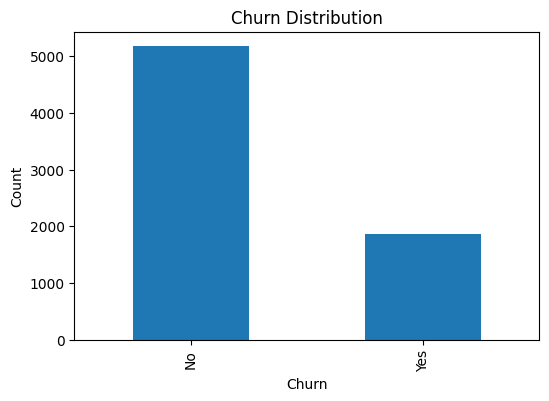

In [11]:
plt.figure(figsize=(6,4))
df['Churn'].value_counts().plot(kind='bar')
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

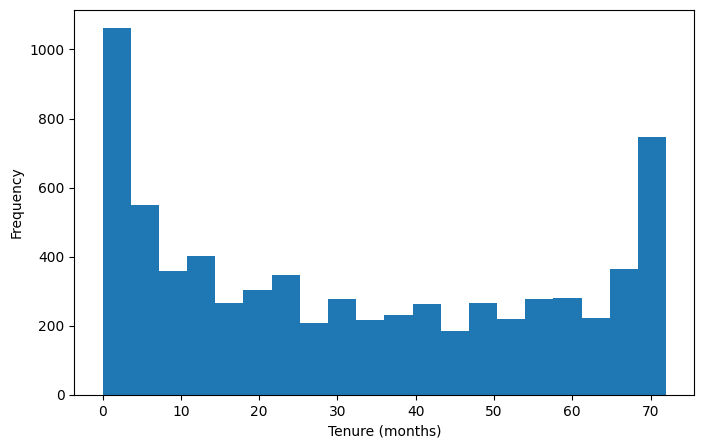

In [12]:
plt.figure(figsize=(8,5))
plt.hist(df['tenure'], bins=20)
plt.title("")
plt.xlabel("Tenure (months)")
plt.ylabel("Frequency")
plt.show()

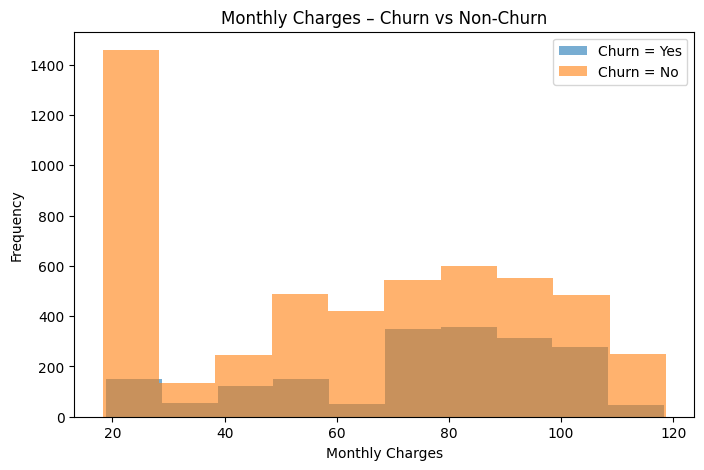

In [13]:
plt.figure(figsize=(8,5))
df[df['Churn']=="Yes"]['MonthlyCharges'].plot(kind='hist', alpha=0.6, label="Churn = Yes")
df[df['Churn']=="No"]['MonthlyCharges'].plot(kind='hist', alpha=0.6, label="Churn = No")
plt.legend()
plt.title("Monthly Charges – Churn vs Non-Churn")
plt.xlabel("Monthly Charges")
plt.show()

<Figure size 700x400 with 0 Axes>

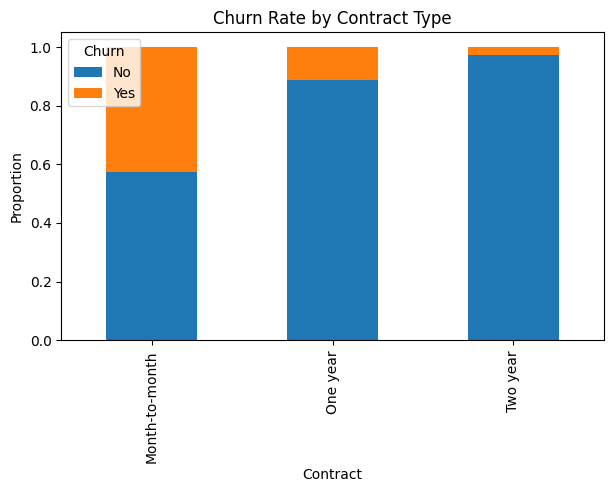

In [14]:
plt.figure(figsize=(7,4))
(df.groupby("Contract")['Churn']
   .value_counts(normalize=True)
   .unstack()
   .plot(kind='bar', stacked=True, figsize=(7,4)))
plt.title("Churn Rate by Contract Type")
plt.ylabel("Proportion")
plt.show()

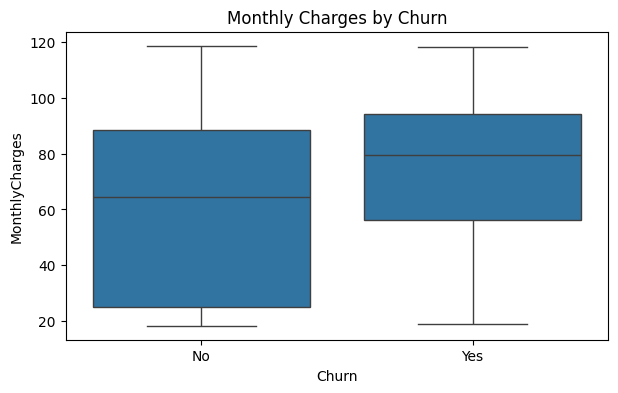

In [15]:
import seaborn as sns

plt.figure(figsize=(7,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges by Churn")
plt.show()

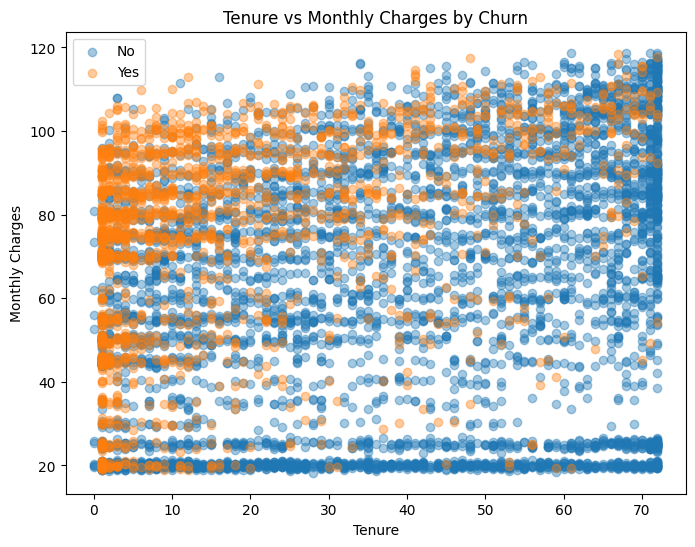

In [16]:
plt.figure(figsize=(8,6))
for label, group in df.groupby('Churn'):
    plt.scatter(group['tenure'], group['MonthlyCharges'], label=label, alpha=0.4)

plt.legend()
plt.title("Tenure vs Monthly Charges by Churn")
plt.xlabel("Tenure")
plt.ylabel("Monthly Charges")
plt.show()

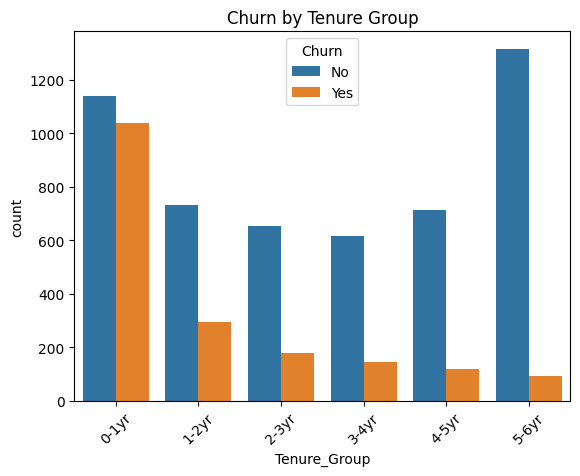

In [17]:
df['Tenure_Group'] = pd.cut(df['tenure'], bins=[0,12,24,36,48,60,72], labels=['0-1yr','1-2yr','2-3yr','3-4yr','4-5yr','5-6yr'])
sns.countplot(x='Tenure_Group', hue='Churn', data=df)
plt.title('Churn by Tenure Group')
plt.xticks(rotation=45)
plt.show()

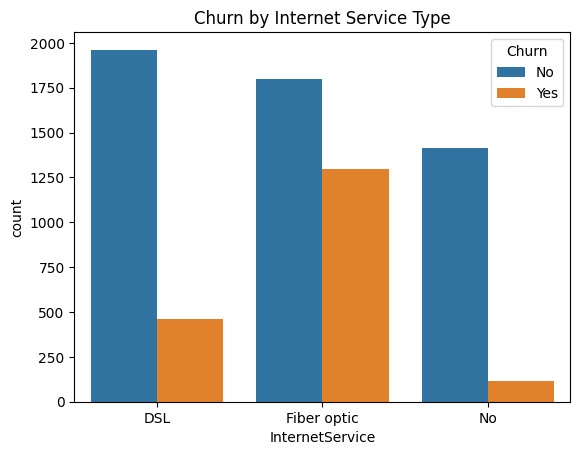

In [18]:
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title('Churn by Internet Service Type')
plt.show()

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.title('Churn by Payment Method')
plt.show()

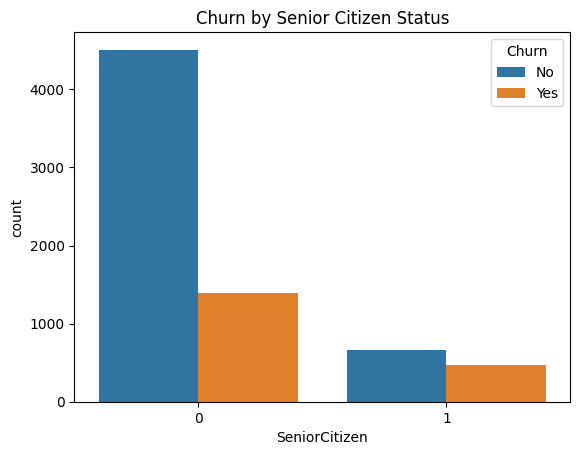

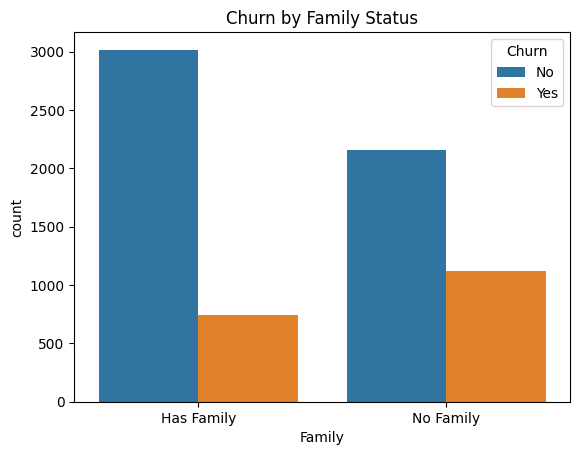

In [19]:
# Combine Partner and Dependents
df['Family'] = ((df['Partner']=='Yes') | (df['Dependents']=='Yes')).map({True:'Has Family', False:'No Family'})
sns.countplot(x='SeniorCitizen', hue='Churn', data=df)
plt.title('Churn by Senior Citizen Status')
plt.show()

sns.countplot(x='Family', hue='Churn', data=df)
plt.title('Churn by Family Status')
plt.show()

# Preprocessing

In [64]:
df = shuffle(df, random_state=42)

In [62]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [63]:
df.drop('customerID' , axis = 1 , inplace = True)


In [65]:
print(X.isnull().sum()[X.isnull().sum() > 0])
print(f"Total NaN cells: {X.isnull().sum().sum()}")

Series([], dtype: int64)
Total NaN cells: 0


In [66]:
X = pd.get_dummies(X , drop_first=True)

In [67]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')  # or 'mean'
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

In [68]:
print(X.isnull().sum()[X.isnull().sum() > 0])
print(f"Total NaN cells: {X.isnull().sum().sum()}")

Series([], dtype: int64)
Total NaN cells: 0


In [69]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [70]:
y = y.map({'Yes':1, 'No':0})

In [71]:
X.shape

(7043, 19)

In [72]:
y.shape

(7043,)

In [73]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [74]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in X_train.select_dtypes(include='object').columns:
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

In [75]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [76]:
X_train.shape

(5634, 19)

In [77]:
X_test.shape

(1409, 19)

In [78]:
y_train.shape

(5634,)

In [79]:
y_test.shape

(1409,)

# Decision Tree Implementation
To develop an interpretable and effective Entropy-based Decision Tree model that predicts whether a customer is likely to churn using behavioral and demographic information.


Expected Outcomes

* A fully trained Entropy-based Decision Tree for churn prediction

* Identification of major factors influencing churn through information gain

* Performance metrics demonstrating prediction effectiveness

In [85]:
clf_entropy = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42,
    max_depth=3,
    min_samples_leaf=5
)

In [86]:
clf_entropy.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, min_samples_leaf=5,
                       random_state=42)

In [87]:
y_pred_entropy = clf_entropy.predict(X_test)
y_pred_entropy

array([0, 1, 0, ..., 0, 0, 0])

In [88]:
def evaluate_model(y_true, y_pred, model_name):
    """Comprehensive model evaluation"""
    accuracy = accuracy_score(y_true, y_pred)

    model_name
    print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred,
                              target_names=['No Churn (0)', 'Churn (1)']))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

    return accuracy

Accuracy: 0.7857 (78.57%)

Classification Report:
              precision    recall  f1-score   support

No Churn (0)       0.80      0.94      0.87      1041
   Churn (1)       0.67      0.36      0.46       368

    accuracy                           0.79      1409
   macro avg       0.74      0.65      0.67      1409
weighted avg       0.77      0.79      0.76      1409



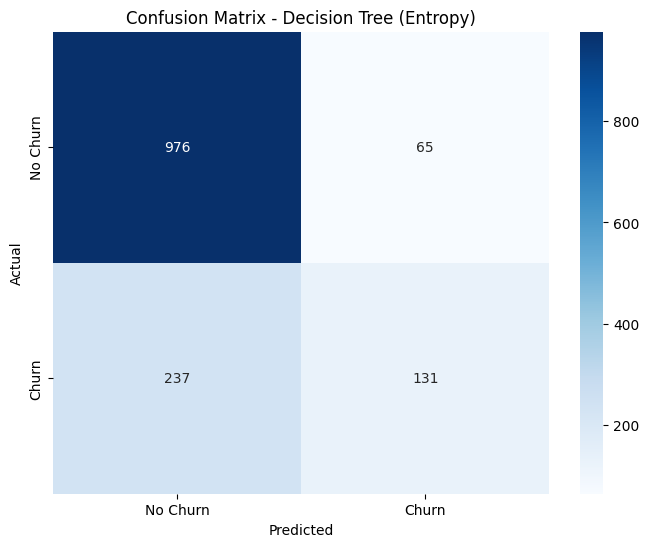

In [89]:
entropy_accuracy = evaluate_model(y_test, y_pred_entropy,"Decision Tree (Entropy)")

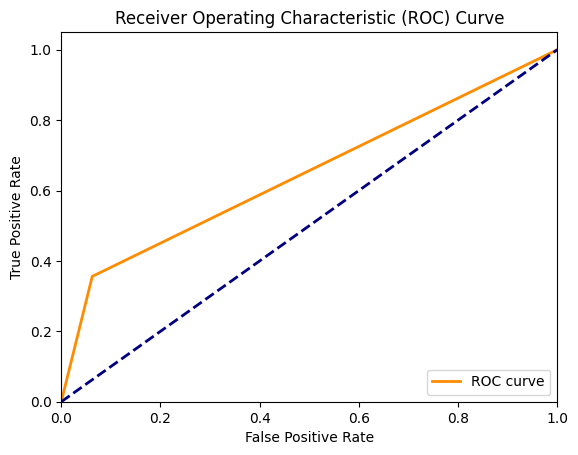

np.float64(0.6467691496470785)

In [90]:
#ROC curve for teh Decision tree
fpr, tpr, thresholds = roc_curve(y_test, y_pred_entropy)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

#ROC accuracy
roc_auc_score(y_test, y_pred_entropy)



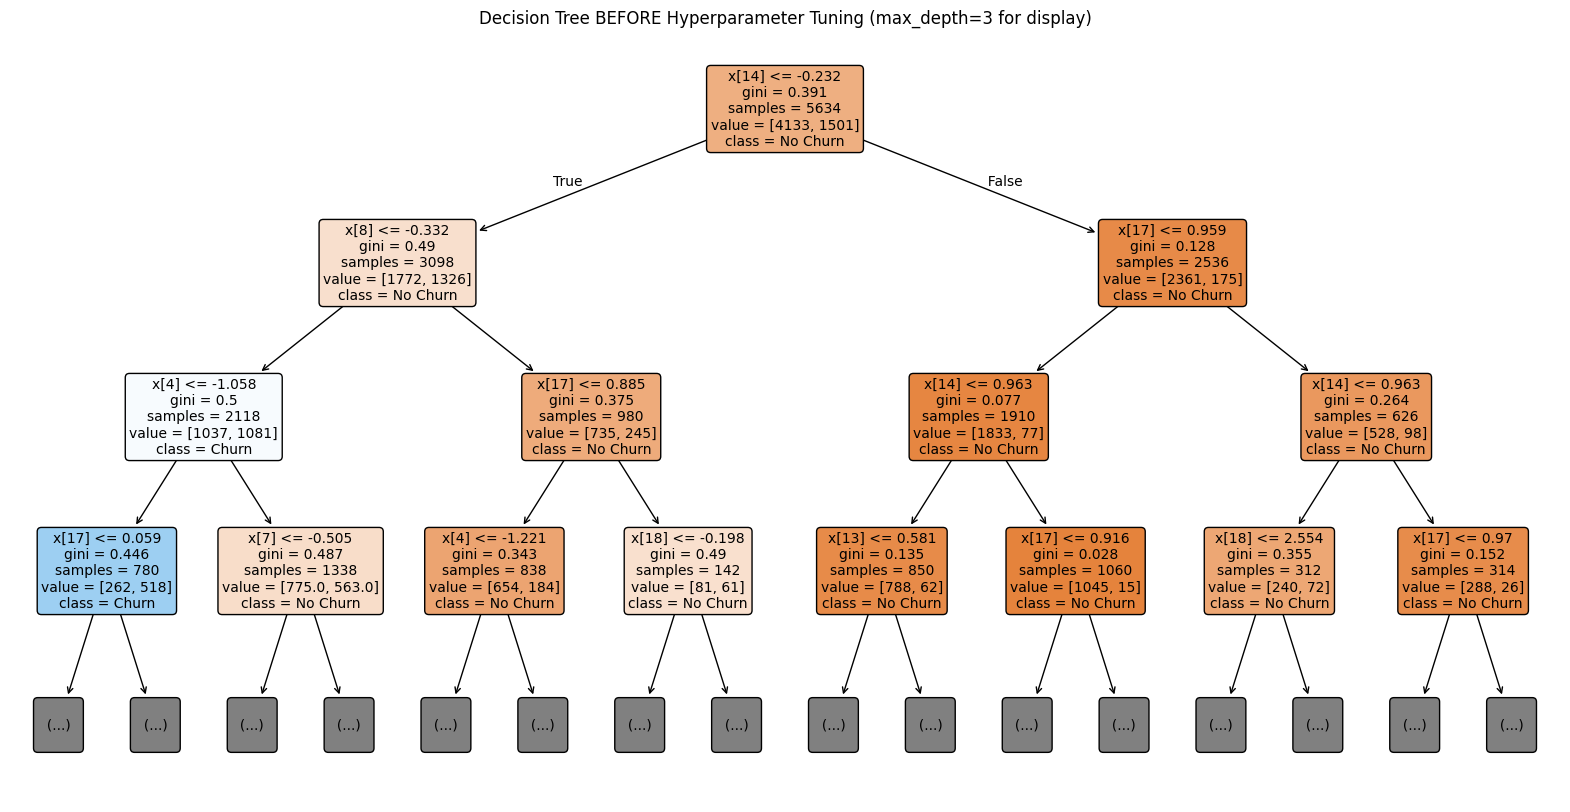

In [91]:
# original tree before tuning
dt_before = DecisionTreeClassifier(random_state=42)
dt_before.fit(X_train, y_train)

# Plot the tree
plt.figure(figsize=(20,10))
tree.plot_tree(dt_before,
               feature_names=X_train.columns if hasattr(X_train, 'columns') else None,
               class_names=['No Churn', 'Churn'],
               filled=True,
               rounded=True,
               fontsize=10,
               max_depth=3)  # Limit depth for readability
plt.title("Decision Tree BEFORE Hyperparameter Tuning (max_depth=3 for display)")
plt.show()

In [92]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10, 20, 30],
    'min_samples_leaf': [1, 2, 5, 10, 15, 20],
    'max_features': [None, 'sqrt', 'log2'],
    'class_weight': [None, 'balanced']
}

dt_random = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=100,
    cv=5,
    scoring='accuracy',
    verbose=2,
    n_jobs=-1,
    random_state=42
)
dt_random.fit(X_train, y_train)

dt_random.best_params_
dt_random.best_score_

# Use the best model
best_dt = dt_random.best_estimator_

# Evaluate on test set
y_pred_dt = best_dt.predict(X_test)
print(classification_report(y_test, y_pred_dt))

accuracy = accuracy_score(y_test, y_pred_dt)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

#ROC accuracy
roc_auc_score(y_test, y_pred_dt)
print("ROC AUC:", roc_auc_score(y_test, y_pred_dt))

Fitting 5 folds for each of 100 candidates, totalling 500 fits
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1041
           1       0.65      0.51      0.57       368

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

Accuracy: 0.8006 (80.06%)
ROC AUC: 0.7051669590276909


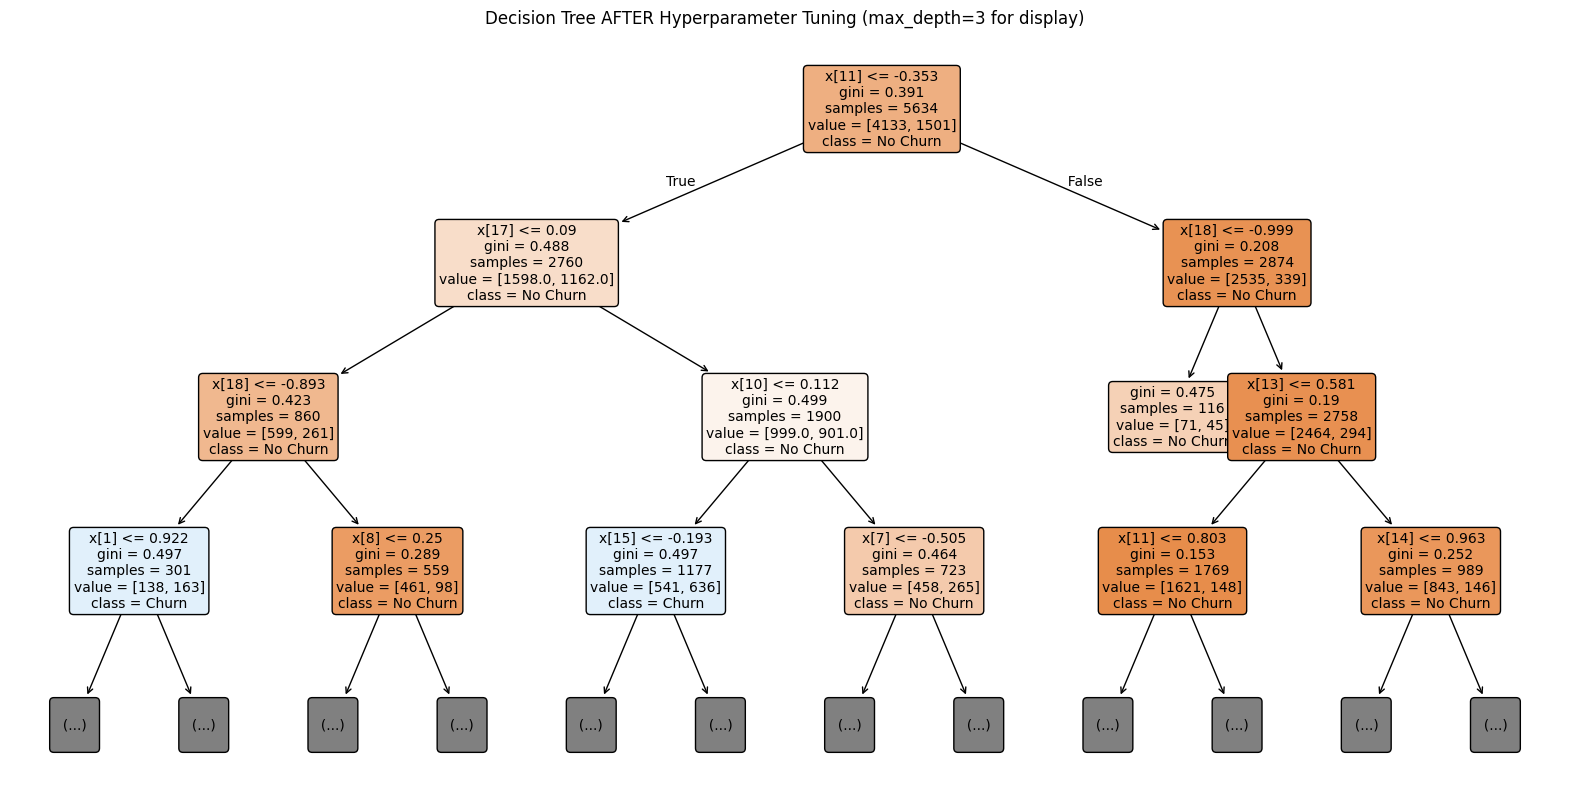

In [93]:
# Distribution if te decision tree after tuning
plt.figure(figsize=(20,10))
tree.plot_tree(best_dt,
               feature_names=X_train.columns if hasattr(X_train, 'columns') else None,
               class_names=['No Churn', 'Churn'],
               filled=True,
               rounded=True,
               fontsize=10,
               max_depth=3)  # Limit depth for readability
plt.title("Decision Tree AFTER Hyperparameter Tuning (max_depth=3 for display)")
plt.show()


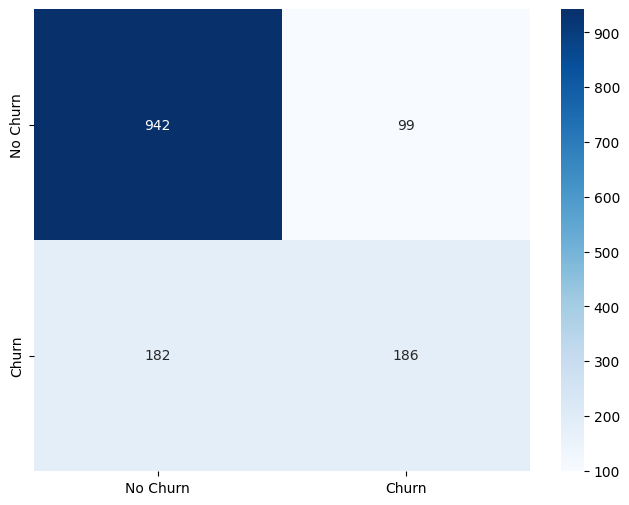

In [94]:
#Confusion metrix for Decision tree
cm = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.show()